# Data set for Function transformation 
    * Boston Housing
    * Wine Quality
    * NYC Taxi Trip Data
    * Airline Flight Delays
    * World Happiness Report


# fucntion transform
        * Red wine data set

In [35]:
import pandas as pd
import numpy as np

import scipy.stats as stats # qq plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [37]:
wine = pd.read_csv('A:\\AIML_DEV_FOLDER\\Dataset_self\\winequality-red.csv')

In [38]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [39]:
wine.shape

(1599, 12)

In [40]:
wine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

# clearly i don't have any missing data 
    * otherwise 
        * mean mode meadnian most reapeatative etc 

check column 

In [41]:
print(wine.columns[0:-1]) 
# -1 will print all data expect last one 
print("----------------------")
print(wine.columns[-1])

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
----------------------
quality


# prepare the data for the iloc

In [42]:
x = wine.iloc[:, 0:-1 ]
y = wine.iloc[:,-1]

print(x.shape)
print(y.shape)

(1599, 11)
(1599,)


In [43]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.8,random_state=55)

# ploting the grap with qq and displot 

C:\Users\manis\AppData\Local\Temp\ipykernel_12200\2413884686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['fixed acidity'])


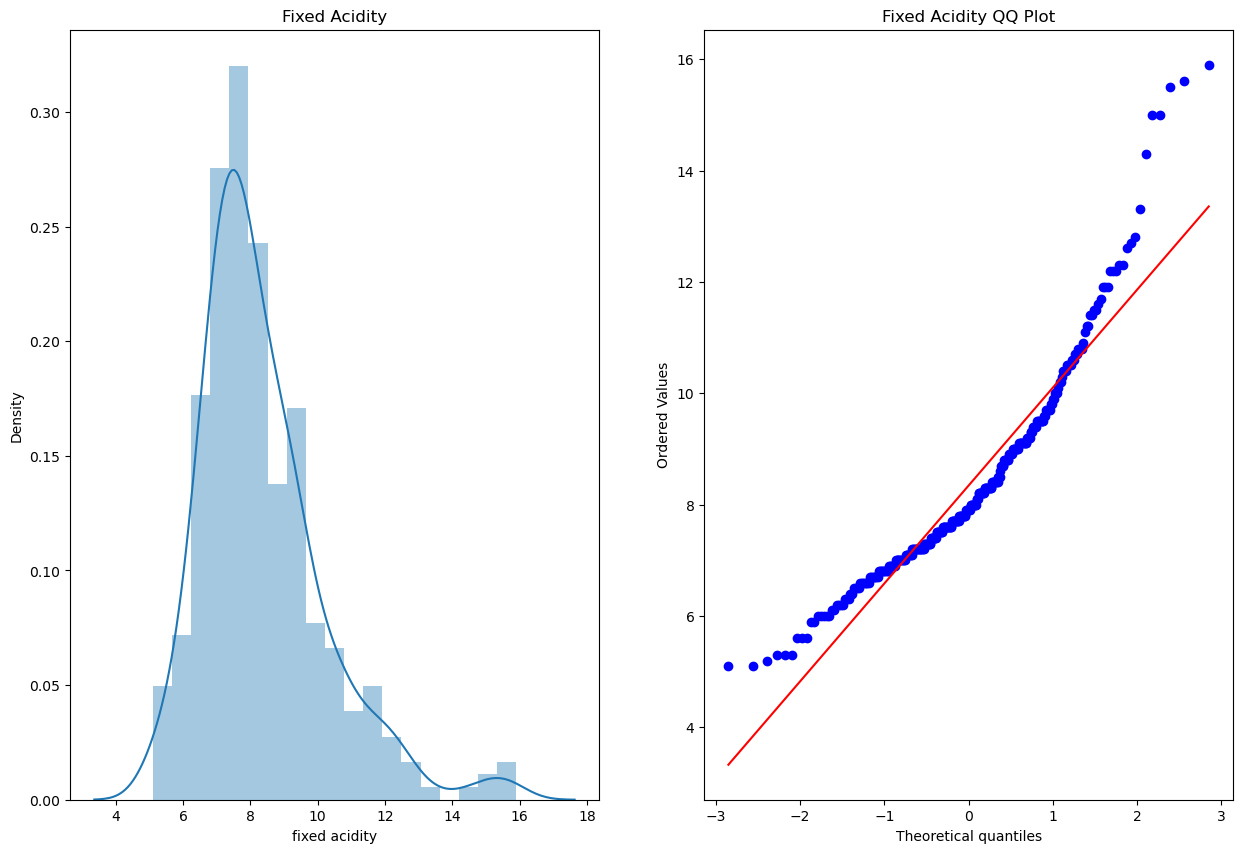

In [44]:
plt.figure(figsize=(15,10))
plt.subplot(121) # So 121 = 1 row, 2 columns, position 1.
sns.distplot(X_train['fixed acidity'])
plt.title('Fixed Acidity')

# QQ plot 
plt.subplot(122)
stats.probplot(X_train['fixed acidity'], dist="norm", plot= plt)
plt.title("Fixed Acidity QQ Plot")
plt.show()

# volatile acidity
qq and dist 

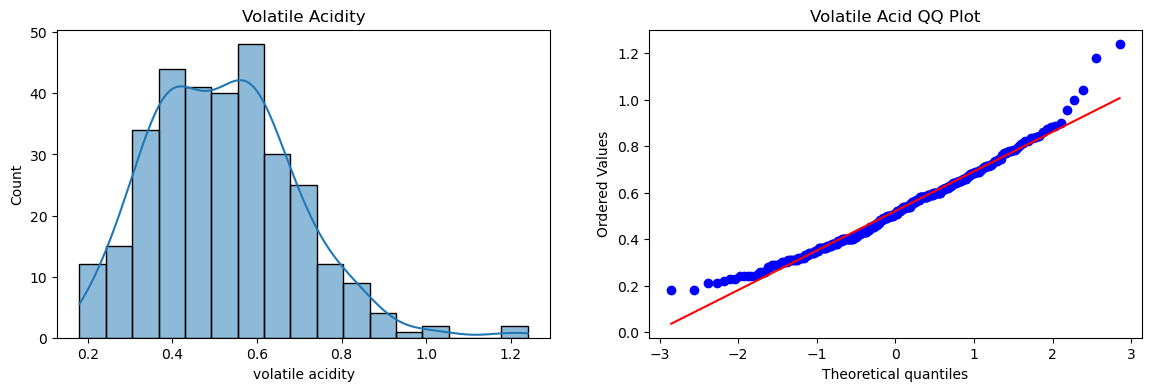

In [45]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['volatile acidity'], kde=True)  # Fixed
plt.title('Volatile Acidity')

plt.subplot(122)
stats.probplot(X_train['volatile acidity'], dist="norm", plot=plt)
plt.title("Volatile Acid QQ Plot")

plt.show()

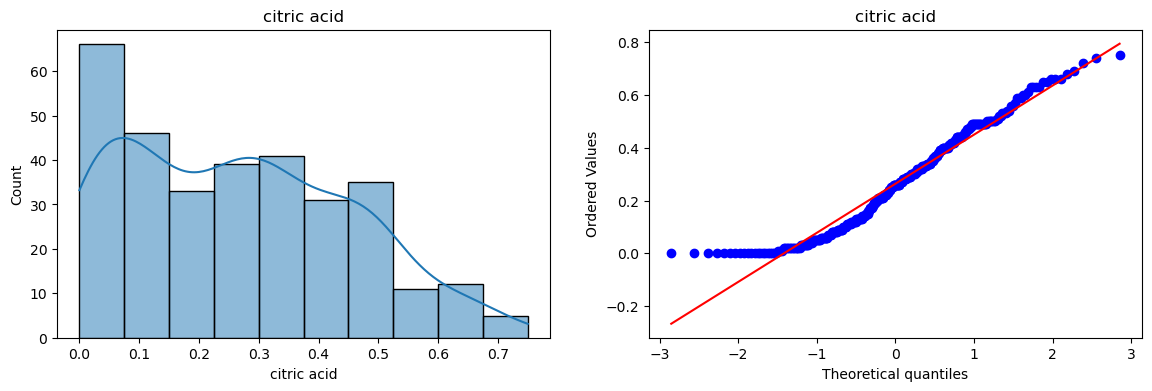

In [46]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['citric acid'], kde=True)  # Fixed
plt.title('citric acid')

plt.subplot(122)
stats.probplot(X_train['citric acid'], dist="norm", plot=plt)
plt.title('citric acid')

plt.show()

residual sugar	chlorides	free sulfur dioxide	total sulfur dioxide	density	pH	sulphates	alcohol


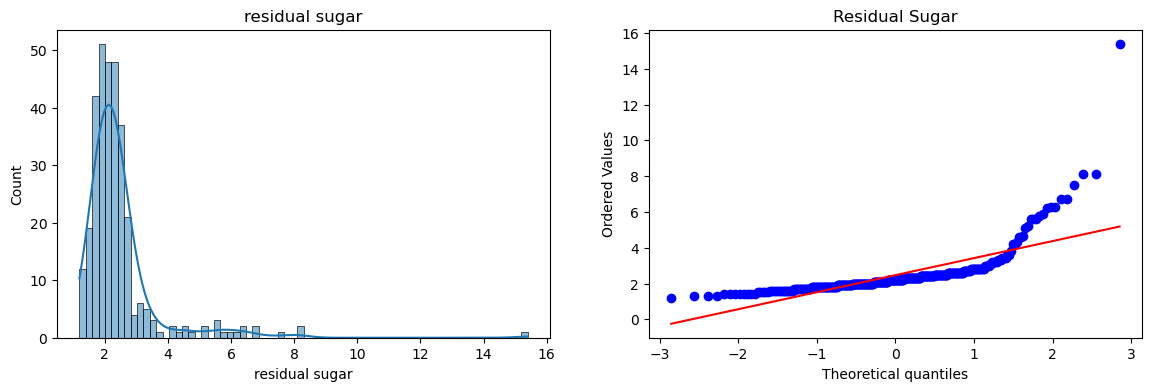

In [47]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['residual sugar'], kde=True)
plt.title("residual sugar")
# qq plot  
plt.subplot(122)
stats.probplot(X_train['residual sugar'], dist="norm", plot=plt)
plt.title('Residual Sugar')

plt.show()




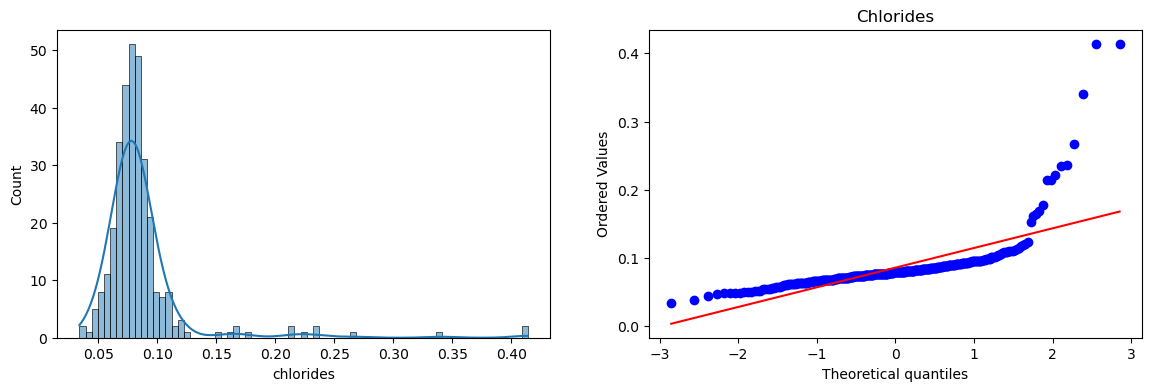

In [48]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['chlorides'], kde=True)  # Fixed plt.title('Chlorides')	
plt.subplot(122)
stats.probplot(X_train['chlorides'], dist="norm", plot=plt)
plt.title("Chlorides")
plt.show()

# free sulfur dioxide

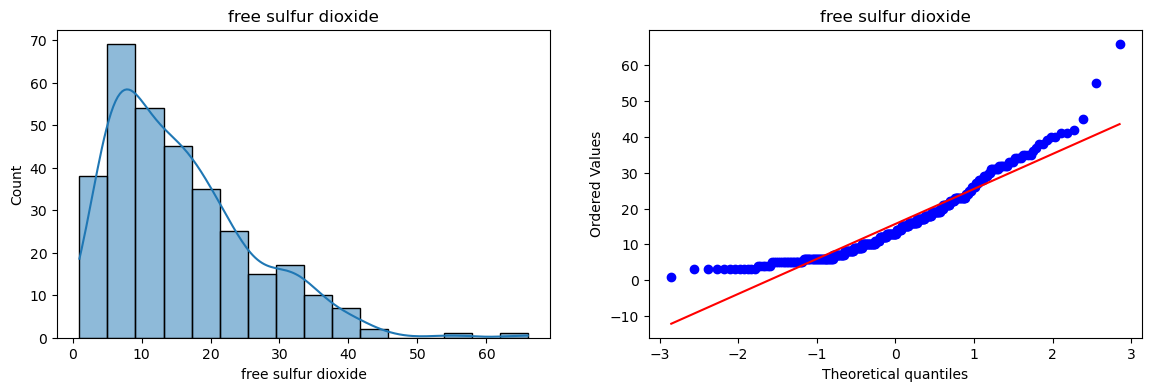

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.title( "Free sulfur Dioxide")
sns.histplot(X_train['free sulfur dioxide'],kde = True)
plt.title("free sulfur dioxide")
plt.subplot(122) 
stats.probplot(X_train['free sulfur dioxide'], dist="norm", plot=plt)
plt.title("free sulfur dioxide")
plt.show()

# code explained 
    * Counts how many columns are in that Index from X_train 
    * fig, axes
        * fig controls the whole window (size, title, background, saving)
        * axes are individual charts inside it
    * for index and col histogram 
    * 0  histogram and qq 
    * ax=axes[idx, 0] for your postion 


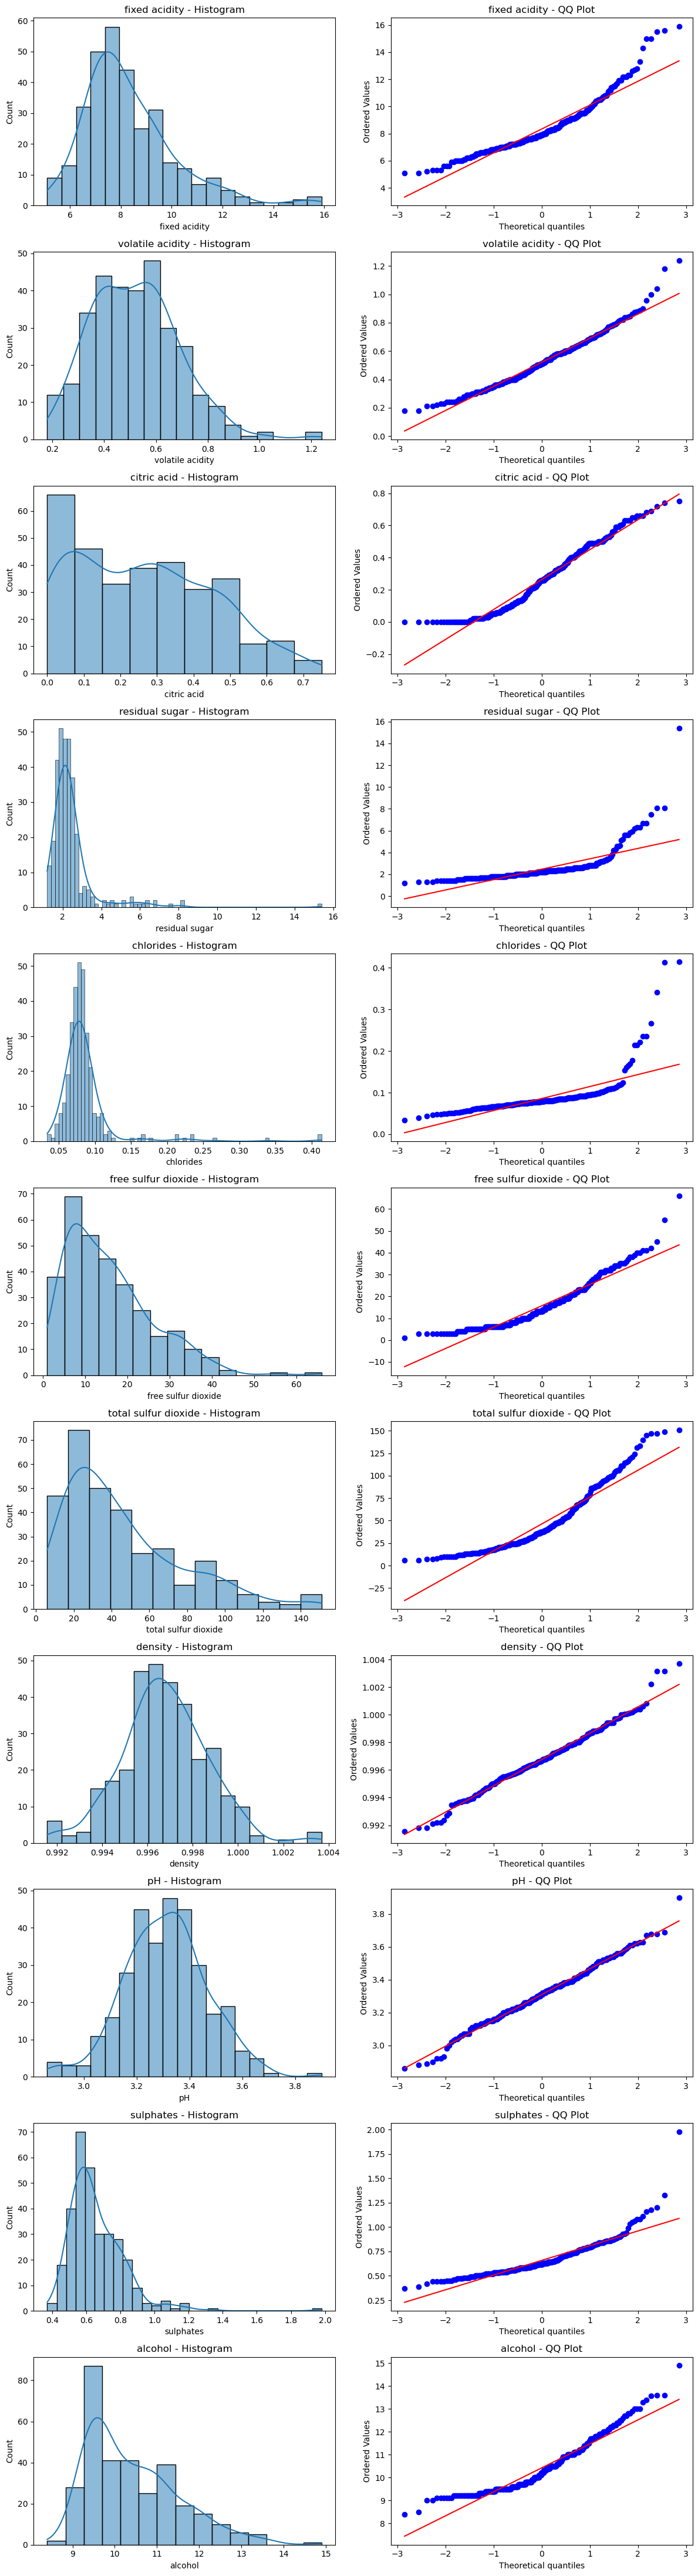

In [ ]:
num_cols = len(X_train.columns)  # Counts how many columns are in that Index
fig, axes = plt.subplots(num_cols, 2, figsize=(12, 4*num_cols))

for idx, col in enumerate(X_train.columns):
    # Histogram
    sns.histplot(X_train[col], kde=True, ax=axes[idx, 0])  
    axes[idx, 0].set_title(f'{col} - Histogram')
    
    # QQ Plot  
    stats.probplot(X_train[col], dist="norm", plot=axes[idx, 1])
    axes[idx, 1].set_title(f'{col} - QQ Plot')

plt.tight_layout()
plt.show()

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [ ]:
clf.fit( X_train,y_train)
clf2.fit(X_test, y_test)
y_predection = clf.predict(X_test)
y_predection_DTC= clf2.predict(X_test)
print("accuracy_score of LR ",accuracy_score(y_test,y_predection))
print("Accuray of DTC", accuracy_score(y_test,y_predection_DTC))


accuracy_score of LR  0.57109375
Accuray of DTC 1.0


c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 1 transforma

# Make of trf1 

# np.log1p add  1 to each value 

In [ ]:
trf = FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)
y_predection = clf.predict(X_test_transformed)
y_predection_DTC = clf.predict(X_test_transformed)
print(" accuracy_score lR ",accuracy_score(y_test,y_predection))
print(" accuracy_score DTC ",accuracy_score(y_test,y_predection_DTC))

 accuracy_score lR  0.5625
 accuracy_score DTC  0.5625


c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# CRoss validate
cross_vale  s test 10 time then find mean 

In [ ]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10))) # 10 time
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10))) # 10 time 

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

LR 0.5690801886792453
DT 0.47592374213836475


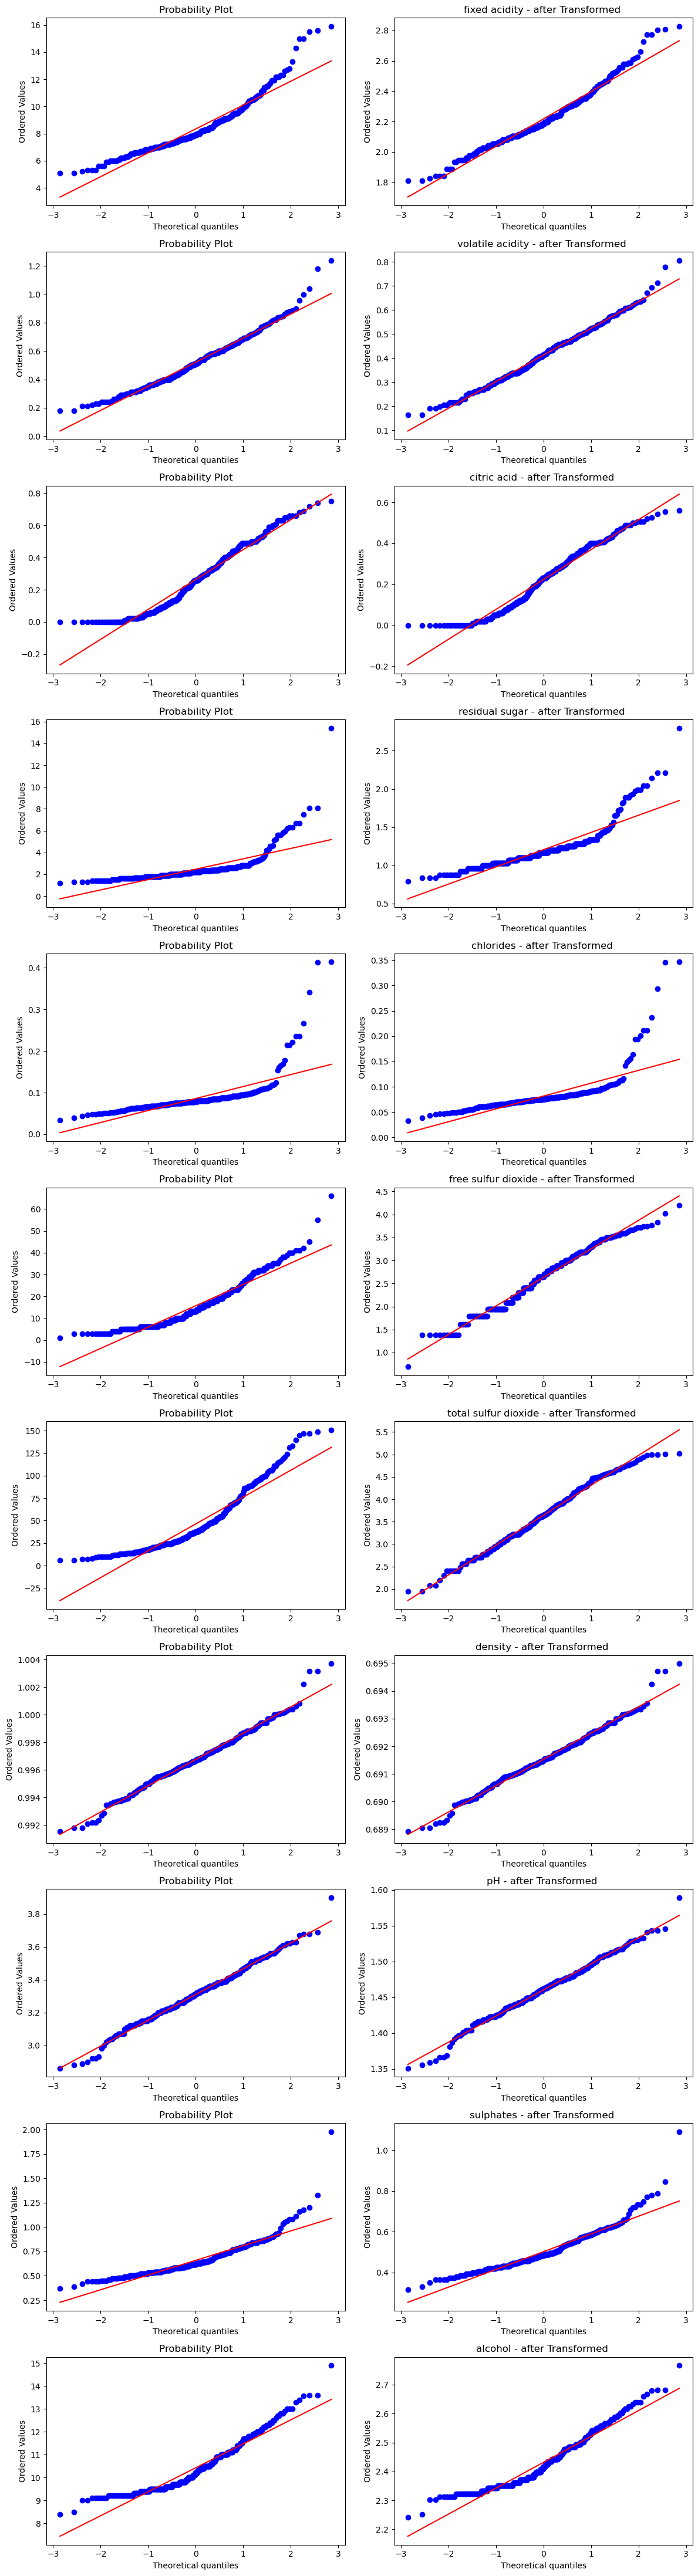

In [ ]:
num_cols = len(X_train.columns)  # Counts how many columns are in that Index
fig, axes = plt.subplots(num_cols, 2, figsize=(12, 4*num_cols))

for idx, col in enumerate(X_train.columns):
    # Before transfroemd
      stats.probplot(X_train[col], dist="norm", plot=axes[idx, 0])
    
    # QQ Plot  
      stats.probplot(X_train_transformed[col], dist="norm", plot=axes[idx, 1])
      
      axes[idx, 1].set_title(f'{col} - after Transformed ')

plt.tight_layout()
plt.show()

# TRf2 no need jus extra

In [ ]:
trf_log = FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed2 = trf_log.fit_transform(X_train_transformed)
X_test_transformed2 = trf_log.transform(X_test)


In [ ]:
clf = LogisticRegression()
clf2= DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 =  clf2.predict(X_test_transformed2)

print( "accuracy_score of LR ",accuracy_score (y_test,y_pred))
print( "accuracy_score of DT ",accuracy_score (y_test,y_pred2))

accuracy_score of LR  0.45625
accuracy_score of DT  0.18828125


c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
X_transformed2 = trf_log.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

LR 0.5690801886792453
DT 0.4759473270440252


# skip above till trf2

In [ ]:
# def apply_transfrom(transform):
#     x = wine.iloc[:, 0:-1 ]
#     y = wine.iloc[:,-1]

#     trf = ColumnTransformer([('log ', FunctionTransformer(transform),
#      ['fixed acidity'],	['volatile acidity'],	['citric acid'],	['residual sugar'],	['chlorides'],	['free sulfur dioxide'],	['total sulfur dioxide'],	['density'],	['pH	'],['sulphates'],['alcohol'],
# )],remainder='passthrough') # although it not needed but it can be useful in
# X_tranfrom_final = trf.fit_transform(x)
# clf = LogisticRegression()
# print("accuracy", np.mean(cross_val_score(clf,X_tranfrom_final,y,scoring='accuracy',cv=10)))

# num_cols = len(X_train.columns) 
# fig,axes = plt.subplot(num_cols, 2, figsize=(12,4*num_cols))
# for idx, col in enumerate(X_train.columns ):
#     stats.probplot(X_train[col],dist="norm",plot=axes[idx,0])
#     axes[idx,0].set_title(f'{col}- before transformation')
#     stats.probplot(X_train[col],dist="norm",plot= axes[idx,1])
#     axes[idx,1].set_title(f'{col}- after Transformed ')
# plt.tight_layout()
# plt.show()




In [ ]:
def apply_transform(transform):
    X = wine.iloc[:, 0:-1]
    y = wine.iloc[:, -1]

    # Correct column list for ColumnTransformer
    cols_to_transform = X.columns.tolist()
    
    trf = ColumnTransformer([
        ('transform', FunctionTransformer(transform), cols_to_transform)
    ], remainder='passthrough')
    
    X_transformed = trf.fit_transform(X)
    
    clf = LogisticRegression()
    print("Accuracy:", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))

    num_cols = len(X.columns)
    fig, axes = plt.subplots(num_cols, 2, figsize=(12, 4*num_cols))
    
    for idx, col in enumerate(X.columns):
        # Before transform
        stats.probplot(X[col], dist="norm", plot=axes[idx, 0])
        axes[idx, 0].set_title(f'{col} - before')
        
        # After transform - use correct index
        stats.probplot(X_transformed[:, idx], dist="norm", plot=axes[idx, 1])
        axes[idx, 1].set_title(f'{col} - after')
    
    plt.tight_layout()
    plt.show()

Accuracy: 0.5572366352201257


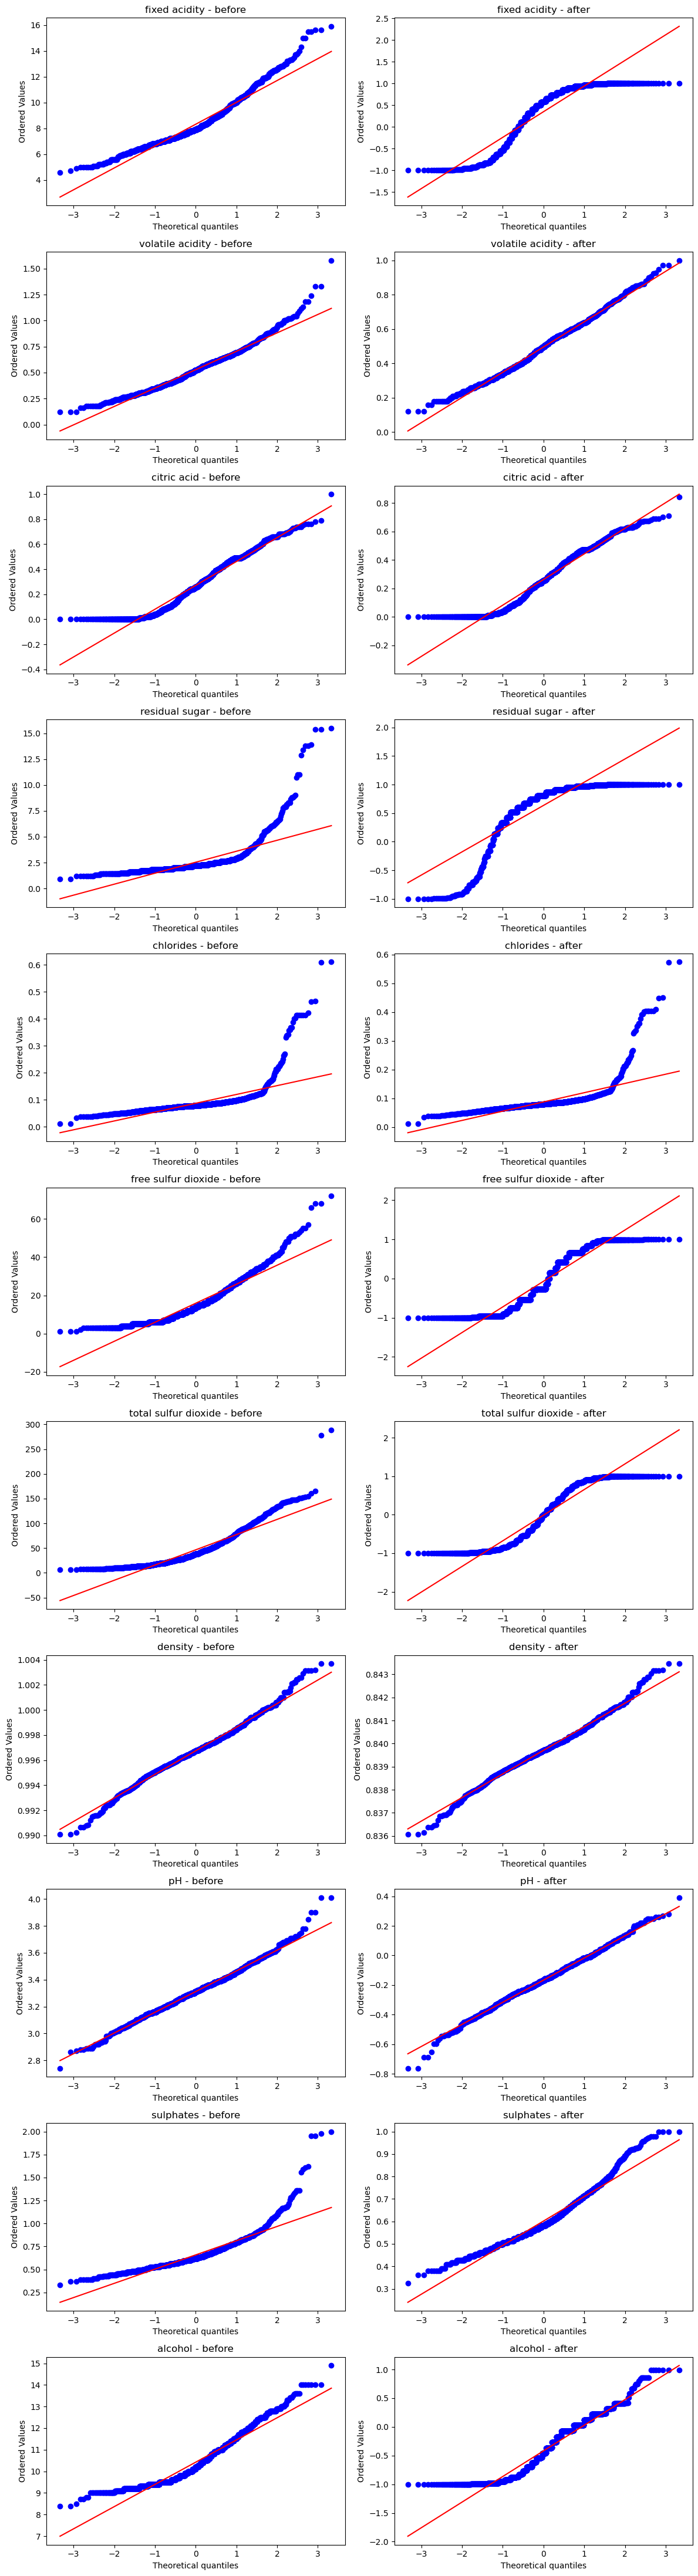

In [ ]:
apply_transform(np.sin)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 0.5797287735849056


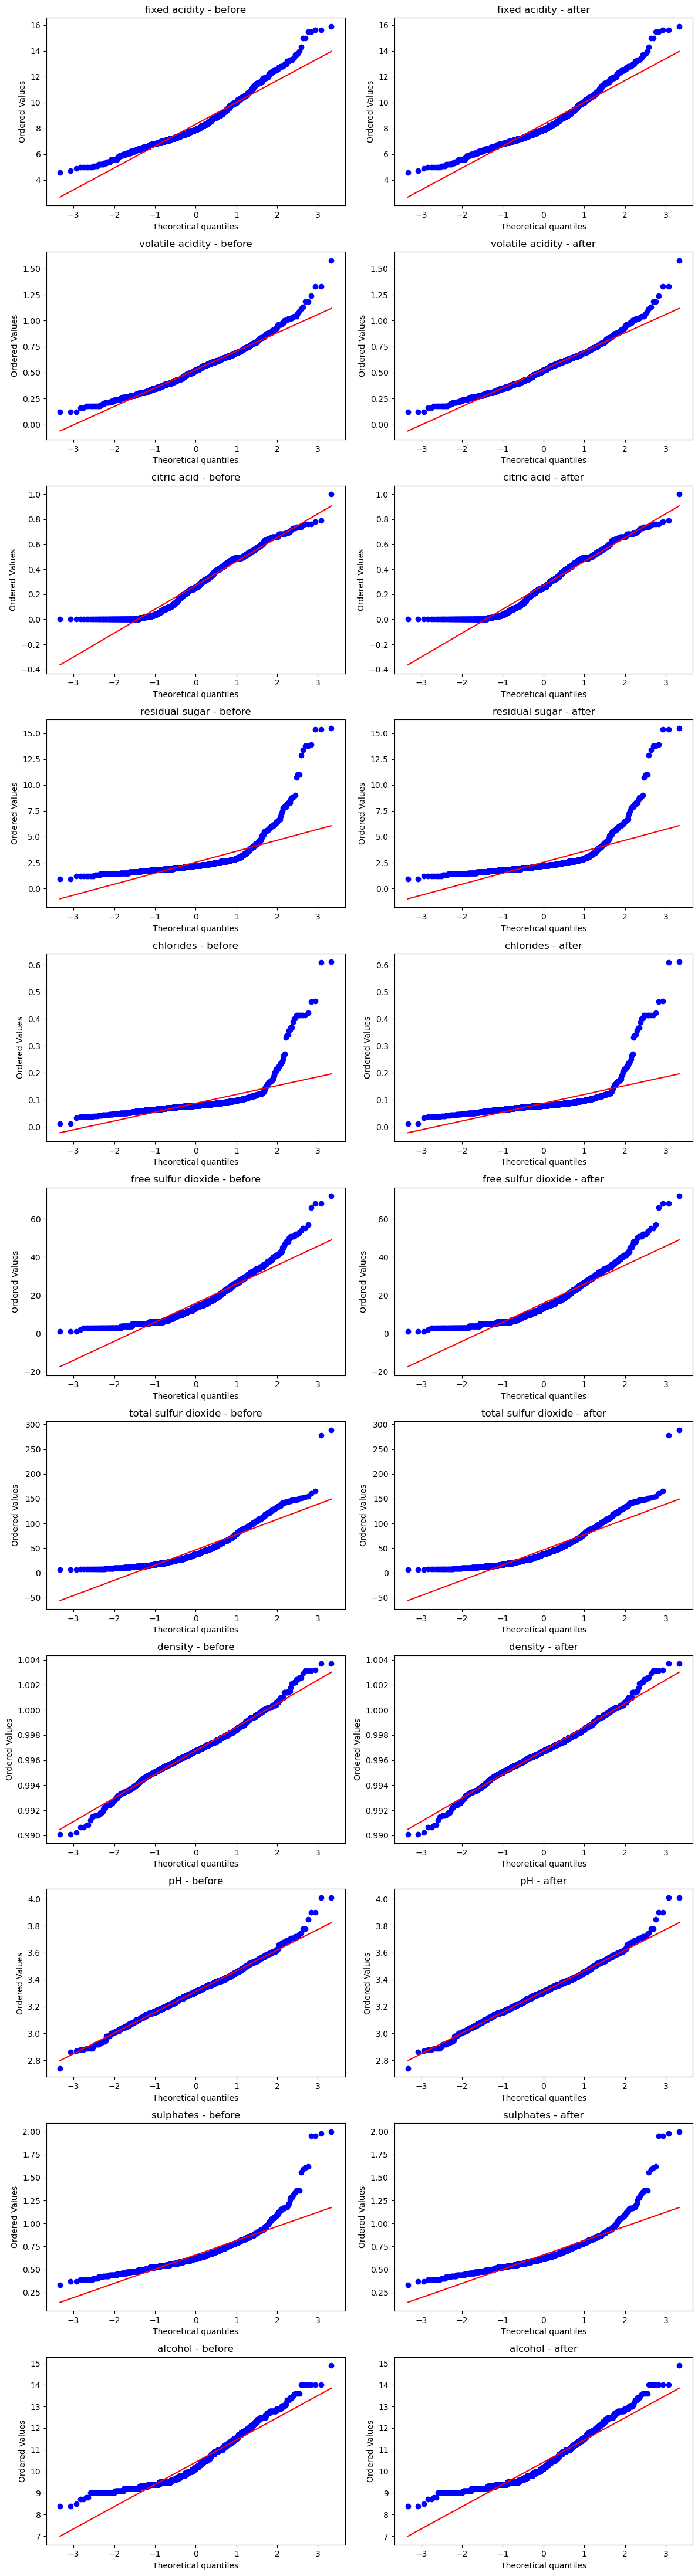

In [ ]:
apply_transform(lambda x:x)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 0.4840369496855345


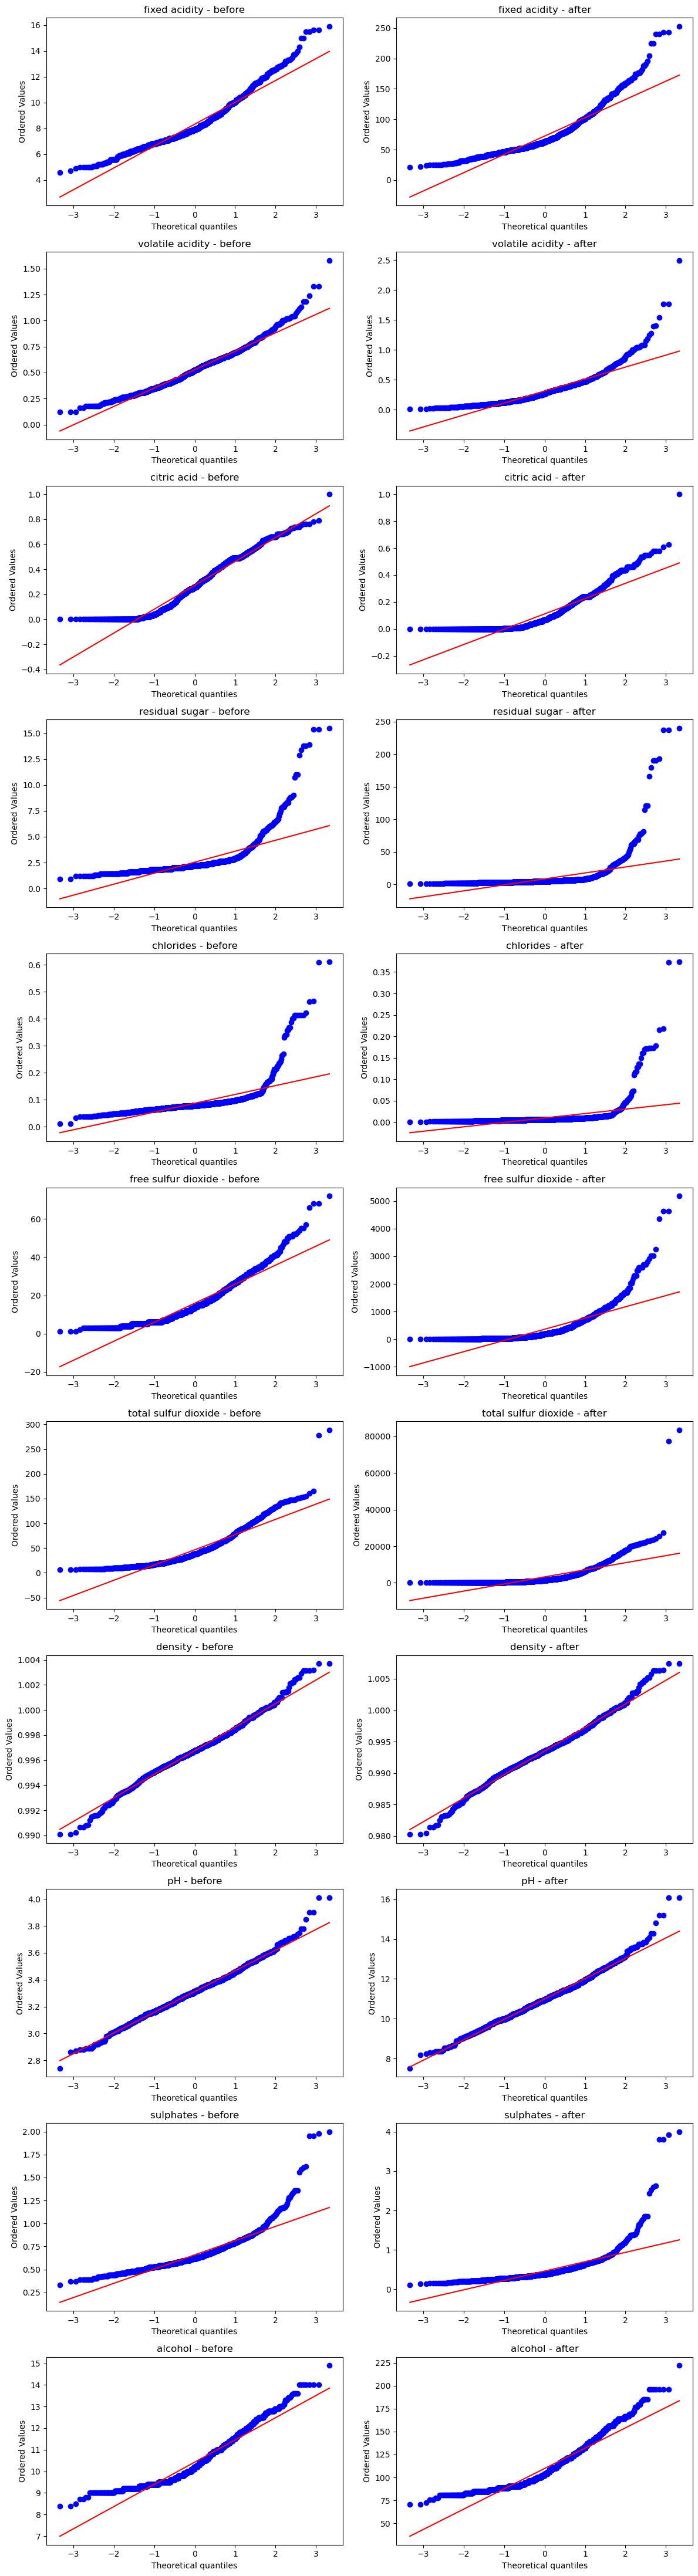

In [ ]:
apply_transform(lambda x:x**2)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 0.5809709119496855


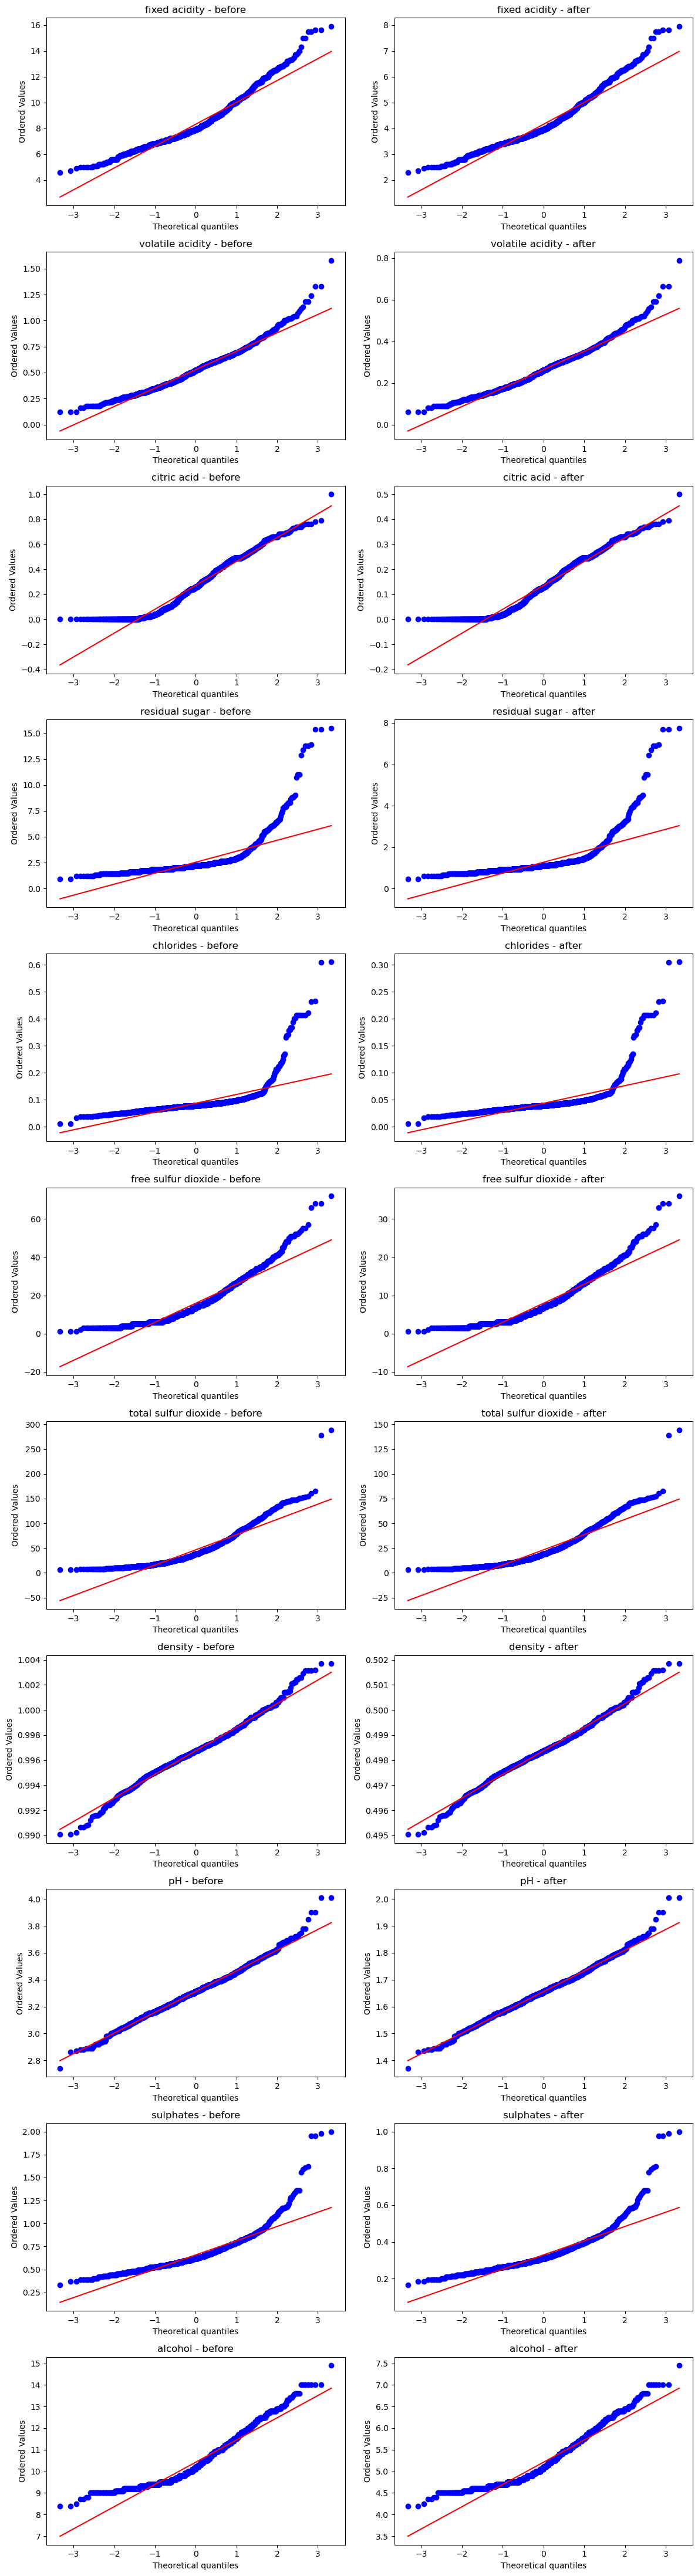

In [ ]:
apply_transform(lambda x:x**1/2)

Accuracy: 0.42274764150943395


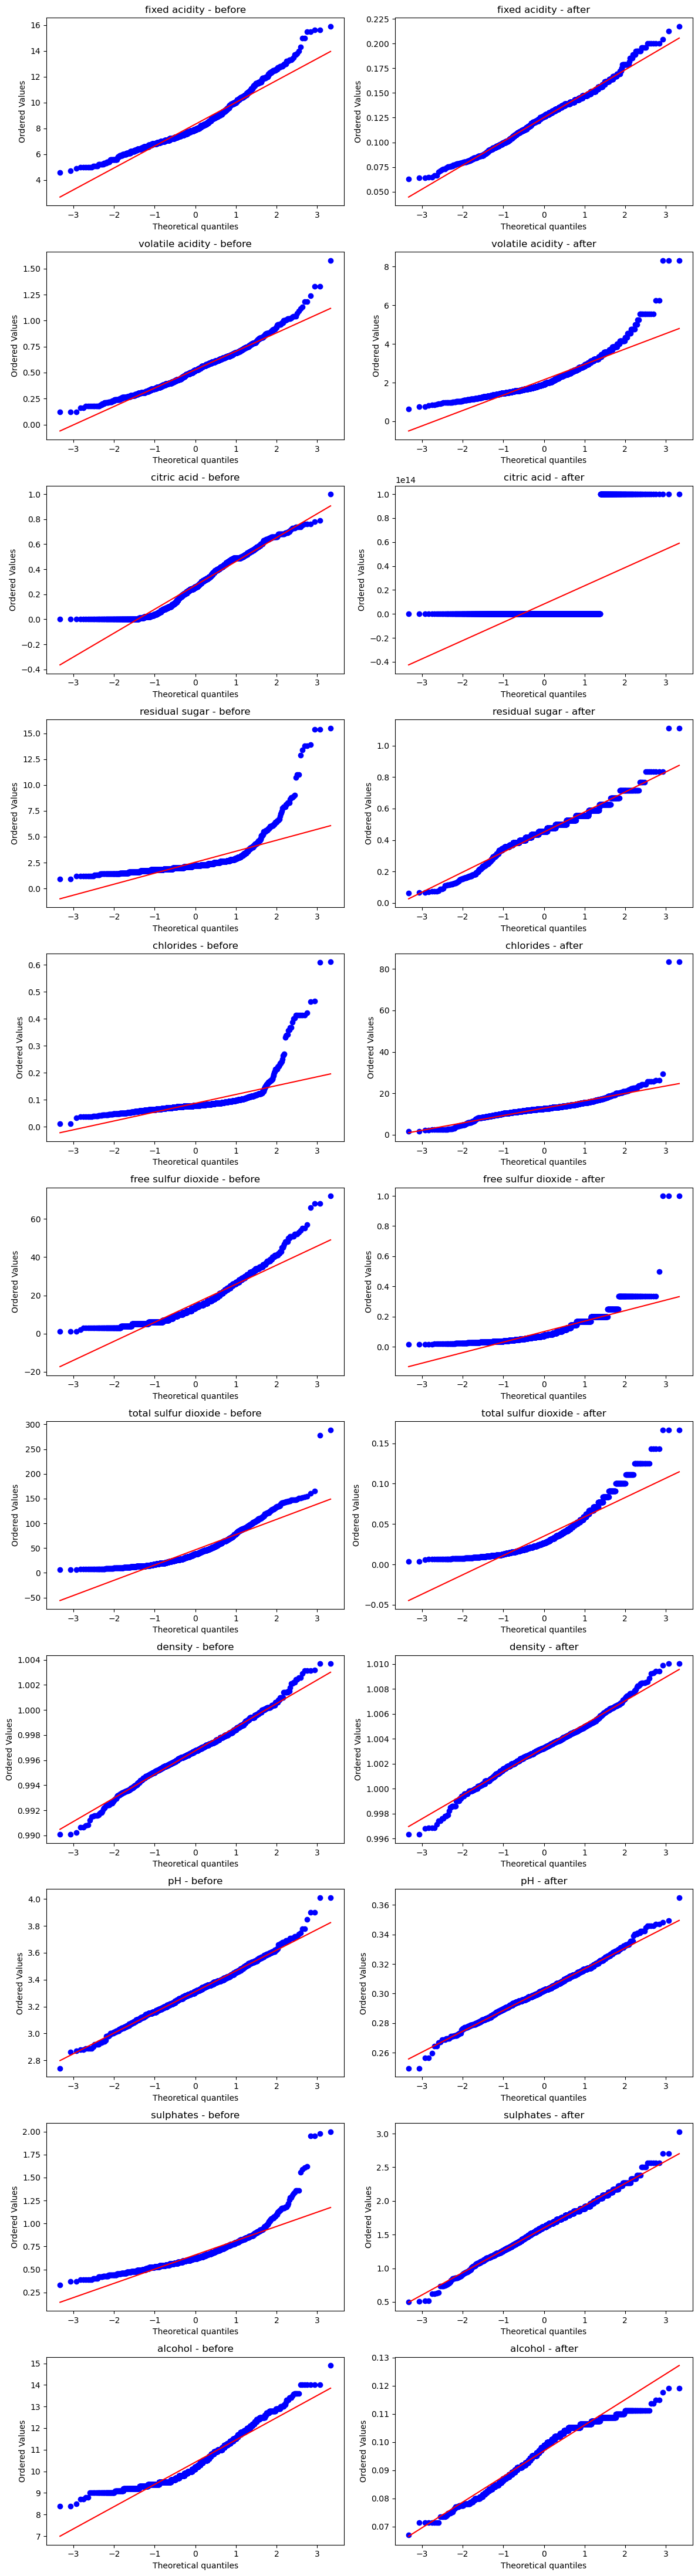

In [ ]:
apply_transform(lambda x:1/(x+0.00000000000001))